In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/home/vlad/eQTL/processed/df_model.csv")

print(f"Shape: {df.shape}")
print(df['target_4class'].value_counts())
print(df['target_3class'].value_counts())

Shape: (489545, 23)
target_4class
real_high    202421
uncertain    175559
artifact      66905
real_mid      44660
Name: count, dtype: int64
target_3class
real         247081
uncertain    175559
artifact      66905
Name: count, dtype: int64


In [4]:
FEATURE_COLS = [c for c in df.columns if c not in ['target_3class', 'target_4class']]

X = df[FEATURE_COLS]
y_4 = df['target_4class']
y_3 = df['target_3class']

X_train, X_test, y4_train, y4_test, y3_train, y3_test = train_test_split(
    X, y_4, y_3,
    test_size = 0.2,
    stratify = y_4,
    random_state = 67   
)

In [5]:
from sklearn.utils.class_weight import compute_class_weight

def get_weights(y):
    classes = np.unique(y)
    weights = compute_class_weight('balanced', classes = classes, y = y)
    return dict(zip(classes, weights))

In [6]:
weights_4 = get_weights(y4_train)
weights_3 = get_weights(y3_train)

In [7]:
print(weights_3)
print(weights_4)

{'artifact': np.float64(2.439005555140373), 'real': np.float64(0.660437271815108), 'uncertain': np.float64(0.9294989094344012)}
{'artifact': np.float64(1.82925416635528), 'real_high': np.float64(0.6046116699704206), 'real_mid': np.float64(2.740399686520376), 'uncertain': np.float64(0.6971241820758008)}


In [9]:
rf_4 = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight= weights_4,
    n_jobs= -1,
    random_state=67
)

rf_4.fit(X_train, y4_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def evaluate_model(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    
    print(f"\n{'='*50}")
    print(f"{title}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred))
    
    # Confusion matrix
    fig, ax = plt.subplots(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred, normalize='true')
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=model.classes_
    )
    disp.plot(ax=ax, cmap='Blues', values_format='.2f')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    
    return y_pred


Random Forest — 4 classes
              precision    recall  f1-score   support

    artifact       0.96      0.61      0.75     13381
   real_high       0.96      0.88      0.92     40484
    real_mid       0.90      0.59      0.71      8932
   uncertain       0.72      0.95      0.82     35112

    accuracy                           0.84     97909
   macro avg       0.88      0.76      0.80     97909
weighted avg       0.87      0.84      0.84     97909



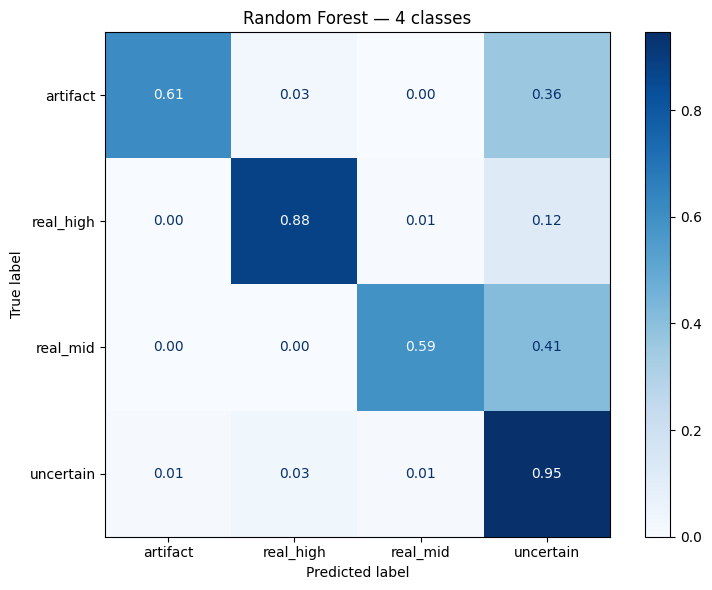

In [9]:
y4_pred = evaluate_model(rf_4, X_test, y4_test, "Random Forest — 4 classes")

In [13]:
rf_3 = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight= weights_3,
    n_jobs= -1,
    random_state=67
)

rf_3.fit(X_train, y3_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y


Random Forest — 3 classes
              precision    recall  f1-score   support

    artifact       0.96      0.61      0.75     13381
        real       0.97      0.82      0.89     49416
   uncertain       0.71      0.96      0.82     35112

    accuracy                           0.84     97909
   macro avg       0.88      0.80      0.82     97909
weighted avg       0.87      0.84      0.84     97909



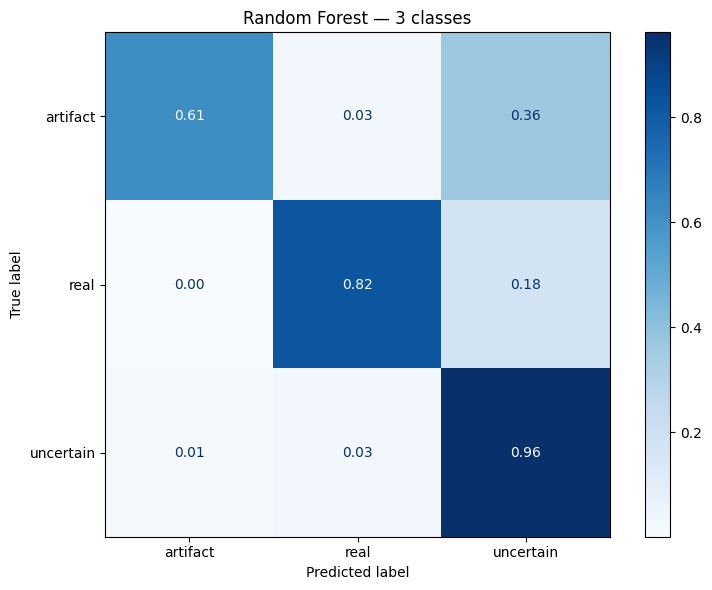

In [14]:
y3_pred = evaluate_model(rf_3, X_test, y3_test, "Random Forest — 3 classes")

First we can see that using 4 classes doesn't have any loss in accuracy, but gives us more information, so we stick with it.

We can see that model confuses artifacts with uncertain really much in both models (0.36), so we will shift weights because its more important to 

artifact_weight=5.0: recall=0.917, precision=0.354, overall_f1=0.729
artifact_weight=8.0: recall=0.956, precision=0.303, overall_f1=0.687
artifact_weight=12.0: recall=0.973, precision=0.284, overall_f1=0.664


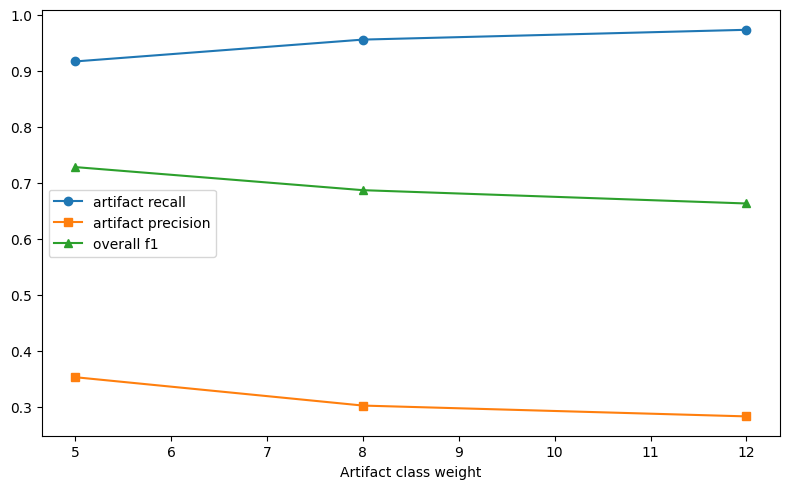

In [8]:
experiments = [
    {'artifact': 5.0,  'real_high': 0.6, 'real_mid': 2.7, 'uncertain': 0.7},
    {'artifact': 8.0,  'real_high': 0.6, 'real_mid': 2.7, 'uncertain': 0.7},
    {'artifact': 12.0, 'real_high': 0.6, 'real_mid': 2.7, 'uncertain': 0.7},
]

results = []

for weights in experiments:
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        class_weight=weights,
        n_jobs=-1,
        random_state=42
    )
    rf.fit(X_train, y4_train)
    y_pred = rf.predict(X_test)
    
    from sklearn.metrics import recall_score, precision_score
    
    artifact_recall = recall_score(y4_test, y_pred, 
                                labels=['artifact'], 
                                average='macro')
    artifact_precision = precision_score(y4_test, y_pred,
                                        labels=['artifact'],
                                        average='macro')
    overall_f1 = classification_report(y4_test, y_pred, output_dict=True)['weighted avg']['f1-score']
    
    results.append({
        'artifact_weight': weights['artifact'],
        'artifact_recall': artifact_recall,
        'artifact_precision': artifact_precision,
        'overall_f1': overall_f1
    })
    print(f"artifact_weight={weights['artifact']}: "
          f"recall={artifact_recall:.3f}, "
          f"precision={artifact_precision:.3f}, "
          f"overall_f1={overall_f1:.3f}")

results_df = pd.DataFrame(results)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(results_df['artifact_weight'], 
        results_df['artifact_recall'], 
        label='artifact recall', marker='o')
ax.plot(results_df['artifact_weight'], 
        results_df['artifact_precision'], 
        label='artifact precision', marker='s')
ax.plot(results_df['artifact_weight'], 
        results_df['overall_f1'], 
        label='overall f1', marker='^')
ax.set_xlabel('Artifact class weight')
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
weigth = {'artifact': 5.0,  'real_high': 0.6, 'real_mid': 2.7, 'uncertain': 0.7}

rf_artifact_focus = RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        class_weight= weigth,
        n_jobs=-1,
        random_state=42
)
rf_artifact_focus.fit(X_train, y4_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [16]:
rf_balanced = rf_4  
rf_focused = rf_artifact_focus  

pred_balanced = rf_balanced.predict(X_test)
pred_focused = rf_focused.predict(X_test)  

mask_changed = (pred_balanced == 'uncertain') & (pred_focused == 'artifact')

print(f"uncertain → artifact: {mask_changed.sum()}")
print(X_test[mask_changed][['length', 'exons', 'perc_A_downstream_TTS', 
                              'has_orf', 'protein_length']].describe())

mask_stayed = (pred_balanced == 'uncertain') & (pred_focused == 'uncertain')
print(f"\nremained uncertain: {mask_stayed.sum()}")
print(X_test[mask_stayed][['length', 'exons', 'perc_A_downstream_TTS',
                            'has_orf', 'protein_length']].describe())

uncertain → artifact: 25935
             length         exons  perc_A_downstream_TTS       has_orf  \
count  25935.000000  25935.000000           25935.000000  25935.000000   
mean       0.685382      0.511635              -0.285324      0.983883   
std        0.777175      0.961188               0.824133      0.125929   
min       -0.885793     -0.931829              -1.506235      0.000000   
25%        0.132195     -0.267689              -0.844314      1.000000   
50%        0.546276      0.285761              -0.513353      1.000000   
75%        1.075741      1.060591               0.148568      1.000000   
max        7.829448     14.232701               5.112979      1.000000   

       protein_length  
count    25935.000000  
mean         0.358958  
std          0.904081  
min         -0.836125  
25%         -0.278826  
50%          0.139148  
75%          0.744412  
max         11.059018  

remained uncertain: 20098
             length         exons  perc_A_downstream_TTS      

In [17]:
train_score = rf_4.score(X_train, y4_train)
test_score = rf_4.score(X_test, y4_test)
print(f"Train accuracy: {train_score:.3f}")
print(f"Test accuracy:  {test_score:.3f}")
print(f"Gap: {train_score - test_score:.3f}")

Train accuracy: 0.847
Test accuracy:  0.840
Gap: 0.007
